In [59]:
# Ensemble Model: Random Forest + XGBoost (base) + LightGBM (meta)
# Designed for Jupyter Notebook with tabular CSV data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

In [60]:
# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("📊 Ensemble Model Setup Complete!")
print("Base Models: Random Forest + XGBoost")
print("Meta Model: LightGBM")
print("-" * 50)

#%% Data Loading and Preprocessing
print("🔄 Loading and preprocessing data...")

# Load your CSV file - replace 'your_data.csv' with your actual file path
data = pd.read_csv('/home/khoim/hcmus_projects/shapG/examples/data/diabetes_binary_health_indicators_BRFSS2015.csv')

# For demonstration, let's create sample data similar to your structure
# Remove this section and uncomment the line above when using your actual data
# np.random.seed(RANDOM_STATE)
# data = pd.DataFrame({
#     **{f'feature_{i}': np.random.randn(20000) for i in range(19)},
#     'target': np.random.choice([0, 1], 20000, p=[0.6, 0.4])
# })

print(f"Data shape: {data.shape}")
print(f"Target distribution:\n{data['Diabetes_binary'].value_counts()}")

# Basic data exploration
print("\n📋 Data Overview:")
print(data.head())
print(f"\nMissing values:\n{data.isnull().sum().sum()} total missing values")

📊 Ensemble Model Setup Complete!
Base Models: Random Forest + XGBoost
Meta Model: LightGBM
--------------------------------------------------
🔄 Loading and preprocessing data...
Data shape: (253680, 22)
Target distribution:
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

📋 Data Overview:
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     

In [61]:
# Separate features and target
# Assuming the last column is the target - adjust as needed
X = data.iloc[:, :-1]  # All columns except the last one
y = data.iloc[:, -1]   # Last column as target

# Handle categorical variables if any
categorical_columns = X.select_dtypes(include=['object']).columns
if len(categorical_columns) > 0:
    print(f"\n🔤 Encoding categorical variables: {list(categorical_columns)}")
    le = LabelEncoder()
    for col in categorical_columns:
        X[col] = le.fit_transform(X[col].astype(str))

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (202944, 21)
Test set size: (50736, 21)


In [62]:
#%% Base Models Definition
print("\n🔧 Setting up base models...")

# Base Model 1: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Base Model 2: XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

print("✅ Base models configured successfully!")

#%% Stacking Implementation
def create_stacking_features(base_models, X_train, y_train, X_test, cv_folds=5):
    """
    Create out-of-fold predictions for stacking
    """
    print(f"\n🔄 Creating stacking features with {cv_folds}-fold CV...")
    
    # Initialize arrays to store out-of-fold predictions
    oof_train = np.zeros((X_train.shape[0], len(base_models)))
    oof_test = np.zeros((X_test.shape[0], len(base_models)))
    
    # Cross-validation setup
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    
    for i, model in enumerate(base_models):
        model_name = model.__class__.__name__
        print(f"  Processing {model_name}...")
        
        # Out-of-fold predictions for training set
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            # Train model on fold
            model.fit(X_fold_train, y_fold_train)
            
            # Predict on validation fold
            oof_train[val_idx, i] = model.predict_proba(X_fold_val)[:, 1]
        
        # Train on full training set and predict test set
        model.fit(X_train, y_train)
        oof_test[:, i] = model.predict_proba(X_test)[:, 1]
        
        print(f"    {model_name} completed!")
    
    return oof_train, oof_test


🔧 Setting up base models...
✅ Base models configured successfully!


In [63]:
base_models = [rf_model, xgb_model]
model_names = ['RandomForest', 'XGBoost']

stacking_train, stacking_test = create_stacking_features(
    base_models, X_train, y_train, X_test, cv_folds=5
)

print("✅ Stacking features created!")

#%% Meta Model (LightGBM)
print("\n🚀 Training meta model (LightGBM)...")

# LightGBM parameters
lgb_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': RANDOM_STATE
}

# Create LightGBM datasets
train_data = lgb.Dataset(stacking_train, label=y_train)
valid_data = lgb.Dataset(stacking_test, label=y_test, reference=train_data)

# Train meta model
meta_model = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=100,
    valid_sets=[valid_data],
    callbacks=[lgb.early_stopping(stopping_rounds=20), lgb.log_evaluation(0)]
)

print("✅ Meta model training completed!")


🔄 Creating stacking features with 5-fold CV...
  Processing RandomForestClassifier...
    RandomForestClassifier completed!
  Processing XGBClassifier...


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4 5 6 7], got [1. 2. 3. 4. 5. 6. 7. 8.]

In [ ]:
print("\n📊 Evaluating ensemble model...")

# Get base model predictions
rf_pred = base_models[0].predict_proba(X_test)[:, 1]
xgb_pred = base_models[1].predict_proba(X_test)[:, 1]

# Get meta model predictions
ensemble_pred_proba = meta_model.predict(stacking_test, num_iteration=meta_model.best_iteration)
ensemble_pred = (ensemble_pred_proba > 0.5).astype(int)

# Calculate accuracies
rf_accuracy = accuracy_score(y_test, (rf_pred > 0.5).astype(int))
xgb_accuracy = accuracy_score(y_test, (xgb_pred > 0.5).astype(int))
ensemble_accuracy = accuracy_score(y_test, ensemble_pred)

print("🎯 Model Performance Comparison:")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print(f"Ensemble Accuracy: {ensemble_accuracy:.4f}")

# Detailed classification report for ensemble
print(f"\n📋 Ensemble Model Classification Report:")
print(classification_report(y_test, ensemble_pred))

#%% Visualizations
print("\n📈 Creating visualizations...")

# Set up the plotting style
plt.style.use('default')
fig = plt.figure(figsize=(15, 10))


📊 Evaluating ensemble model...
🎯 Model Performance Comparison:
Random Forest Accuracy: 0.7990
XGBoost Accuracy: 0.8115
Ensemble Accuracy: 0.8066

📋 Ensemble Model Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.82      2855
           1       0.81      0.77      0.79      2487

    accuracy                           0.81      5342
   macro avg       0.81      0.80      0.81      5342
weighted avg       0.81      0.81      0.81      5342


📈 Creating visualizations...


<Figure size 1500x1000 with 0 Axes>

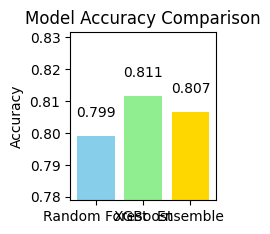

In [ ]:
ax1 = plt.subplot(2, 3, 1)
models = ['Random Forest', 'XGBoost', 'Ensemble']
accuracies = [rf_accuracy, xgb_accuracy, ensemble_accuracy]
bars = plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'gold'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim([min(accuracies) - 0.02, max(accuracies) + 0.02])

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{acc:.3f}', ha='center', va='bottom')

Text(0.5, 225.12222222222223, 'Predicted Label')

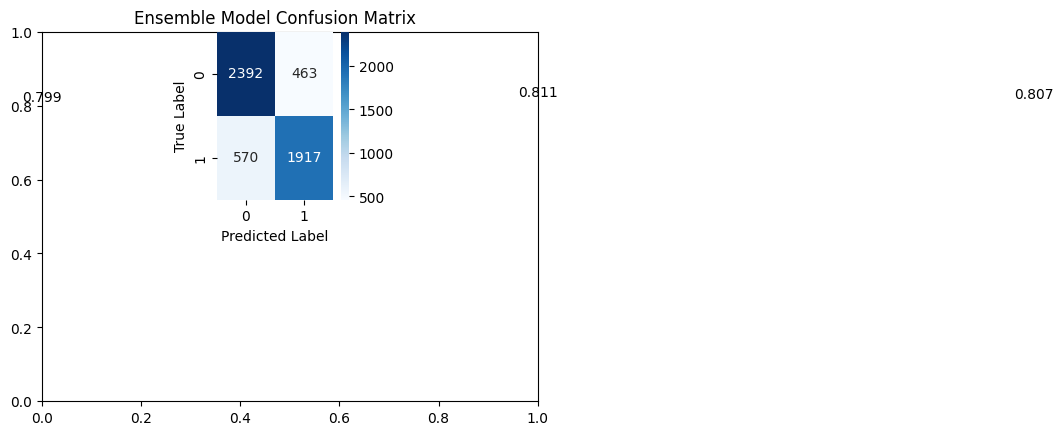

In [ ]:
# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'{acc:.3f}', ha='center', va='bottom')

# 2. Confusion Matrix
ax2 = plt.subplot(2, 3, 2)
cm = confusion_matrix(y_test, ensemble_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Ensemble Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

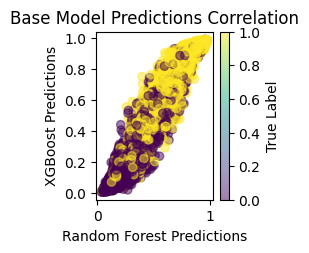

In [ ]:
# 3. Base model predictions correlation
ax3 = plt.subplot(2, 3, 3)
plt.scatter(rf_pred, xgb_pred, alpha=0.5, c=y_test, cmap='viridis')
plt.xlabel('Random Forest Predictions')
plt.ylabel('XGBoost Predictions')
plt.title('Base Model Predictions Correlation')
plt.colorbar(label='True Label')

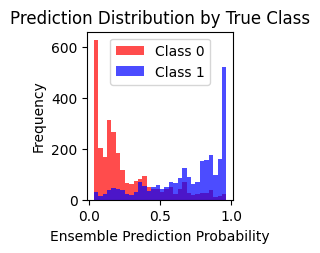

In [ ]:
# 4. Prediction distribution
ax4 = plt.subplot(2, 3, 4)
plt.hist(ensemble_pred_proba[y_test == 0], bins=30, alpha=0.7, label='Class 0', color='red')
plt.hist(ensemble_pred_proba[y_test == 1], bins=30, alpha=0.7, label='Class 1', color='blue')
plt.xlabel('Ensemble Prediction Probability')
plt.ylabel('Frequency')
plt.title('Prediction Distribution by True Class')
plt.legend()

Text(0.5, 1.0, 'Meta Model Feature Importance')

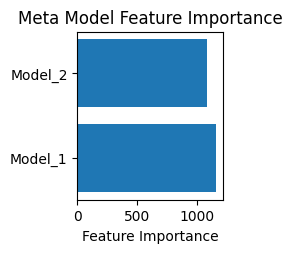

In [ ]:
# 5. Feature importance (LightGBM)
ax5 = plt.subplot(2, 3, 5)
importance = meta_model.feature_importance()
feature_names = [f'Model_{i+1}' for i in range(len(importance))]
plt.barh(feature_names, importance)
plt.xlabel('Feature Importance')
plt.title('Meta Model Feature Importance')

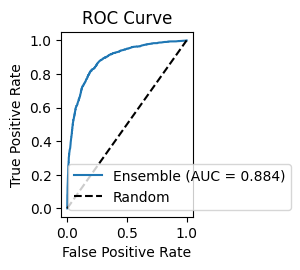

In [ ]:
# 6. ROC-like curve visualization
ax6 = plt.subplot(2, 3, 6)
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_test, ensemble_pred_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'Ensemble (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#%% Model Insights and Summary
print("\n🎯 Model Performance Summary:")
print("=" * 50)
print(f"📊 Dataset: {data.shape[0]:,} samples, {data.shape[1]-1} features")
print(f"🎯 Best Model: {'Ensemble' if ensemble_accuracy == max(accuracies) else models[accuracies.index(max(accuracies))]}")
print(f"🚀 Ensemble Improvement: {ensemble_accuracy - max(rf_accuracy, xgb_accuracy):.4f}")
print(f"📈 Ensemble AUC: {roc_auc:.4f}")

# Cross-validation score for ensemble
print(f"\n🔄 Cross-validation performance:")
cv_scores = cross_val_score(
    lgb.LGBMClassifier(**{k: v for k, v in lgb_params.items() if k not in ['objective', 'metric']}),
    stacking_train, y_train, cv=5, scoring='accuracy'
)
print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

print("\n✅ Analysis Complete! Your ensemble model is ready to use.")


🎯 Model Performance Summary:
📊 Dataset: 26,707 samples, 37 features
🎯 Best Model: XGBoost
🚀 Ensemble Improvement: -0.0049
📈 Ensemble AUC: 0.8838

🔄 Cross-validation performance:
CV Accuracy: 0.8019 (+/- 0.0118)

✅ Analysis Complete! Your ensemble model is ready to use.


In [ ]:
#%% Prediction Function for New Data
def predict_ensemble(new_data):
    """
    Function to make predictions on new data using the trained ensemble
    """
    # Get base model predictions
    rf_pred = base_models[0].predict_proba(new_data)[:, 1].reshape(-1, 1)
    xgb_pred = base_models[1].predict_proba(new_data)[:, 1].reshape(-1, 1)
    
    # Combine base predictions
    stacking_features = np.hstack([rf_pred, xgb_pred])
    
    # Get ensemble prediction
    ensemble_pred = meta_model.predict(stacking_features, num_iteration=meta_model.best_iteration)
    
    return ensemble_pred

#%% R² Score Wrapper Function
from sklearn.metrics import r2_score

def get_ensemble_r2_score(X_data=None, y_true=None, use_test_set=True):
    """
    Wrapper function to calculate and return R² score for the ensemble model
    
    Parameters:
    -----------
    X_data : array-like, optional
        Input features. If None, uses test set
    y_true : array-like, optional
        True target values. If None, uses test set targets
    use_test_set : bool, default=True
        Whether to use the test set when X_data and y_true are None
    
    Returns:
    --------
    float : R² score of the ensemble model
    """
    
    if X_data is None or y_true is None:
        if use_test_set:
            X_data = X_test
            y_true = y_test
            print("📊 Calculating R² score on test set...")
        else:
            X_data = X_train
            y_true = y_train
            print("📊 Calculating R² score on training set...")
    else:
        print("📊 Calculating R² score on provided data...")
    
    # Get ensemble predictions
    predictions = predict_ensemble(X_data)
    
    # Calculate R² score
    r2 = r2_score(y_true, predictions)
    
    print(f"🎯 R² Score: {r2:.6f}")
    
    # Interpretation
    if r2 > 0.9:
        interpretation = "Excellent fit"
    elif r2 > 0.7:
        interpretation = "Good fit"
    elif r2 > 0.5:
        interpretation = "Moderate fit"
    elif r2 > 0:
        interpretation = "Poor fit"
    else:
        interpretation = "Very poor fit (worse than mean baseline)"
    
    print(f"📈 Interpretation: {interpretation}")
    
    return r2

#%% Additional R² Analysis Function
def comprehensive_r2_analysis():
    """
    Comprehensive R² analysis for all models
    """
    print("\n" + "="*60)
    print("🔍 COMPREHENSIVE R² SCORE ANALYSIS")
    print("="*60)
    
    # Get predictions from all models
    rf_pred_test = base_models[0].predict_proba(X_test)[:, 1]
    xgb_pred_test = base_models[1].predict_proba(X_test)[:, 1]
    ensemble_pred_test = predict_ensemble(X_test)
    
    # Calculate R² scores
    rf_r2 = r2_score(y_test, rf_pred_test)
    xgb_r2 = r2_score(y_test, xgb_pred_test)
    ensemble_r2 = r2_score(y_test, ensemble_pred_test)
    
    # Display results
    models_r2 = {
        'Random Forest': rf_r2,
        'XGBoost': xgb_r2,
        'Ensemble': ensemble_r2
    }
    
    print("\n📊 R² Scores Comparison:")
    print("-" * 30)
    for model, score in models_r2.items():
        print(f"{model:15}: {score:8.6f}")
    
    # Find best model
    best_model = max(models_r2.items(), key=lambda x: x[1])
    print(f"\n🏆 Best R² Score: {best_model[0]} ({best_model[1]:.6f})")
    
    # Calculate improvement
    base_models_best = max(rf_r2, xgb_r2)
    improvement = ensemble_r2 - base_models_best
    print(f"📈 Ensemble R² Improvement: {improvement:+.6f}")
    
    return models_r2

# Example usage (uncomment to test):
# r2_score_result = get_ensemble_r2_score()
# all_r2_scores = comprehensive_r2_analysis()

# For integration with external functions:
def get_r2_only():
    """Simple function that returns only the R² score value"""
    return get_ensemble_r2_score()

#%% Quick R² Score Calculation
print("\n🔍 Calculating R² Score for Ensemble Model...")
ensemble_r2 = get_ensemble_r2_score()

print("\n🎉 Ensemble model pipeline complete!")
print("📝 To use with your data:")
print("   1. Replace the sample data loading section with your CSV file")
print("   2. Adjust the target column selection if needed")
print("   3. Run all cells sequentially")
print("   4. Use predict_ensemble() function for new predictions")
print("   5. Use get_ensemble_r2_score() to get R² score")
print("\n💡 Available R² functions:")
print("   - get_ensemble_r2_score(): Detailed R² analysis")
print("   - get_r2_only(): Simple R² value return")
print("   - comprehensive_r2_analysis(): Compare all models' R²")


🔍 Calculating R² Score for Ensemble Model...
📊 Calculating R² score on test set...
🎯 R² Score: 0.451745
📈 Interpretation: Poor fit

🎉 Ensemble model pipeline complete!
📝 To use with your data:
   1. Replace the sample data loading section with your CSV file
   2. Adjust the target column selection if needed
   3. Run all cells sequentially
   4. Use predict_ensemble() function for new predictions
   5. Use get_ensemble_r2_score() to get R² score

💡 Available R² functions:
   - get_ensemble_r2_score(): Detailed R² analysis
   - get_r2_only(): Simple R² value return
   - comprehensive_r2_analysis(): Compare all models' R²
